# KNN Case Study on Diabetes
This is my notebook for the KNN assignment. I'm using the `Diabetes_prediction.csv` file we were given to build and test my model.

In [1]:
# importing the basic libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the dataset
df = pd.read_csv('Diabetes_prediction (1).csv')

# let's see the first few rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diagnosis
0,2,115.863387,56.410731,24.336736,94.385783,26.455940,0.272682,20.100494,0
1,2,92.490122,70.615520,23.443591,138.652426,23.910167,0.665160,44.912281,0
2,1,88.141469,63.262618,23.404364,149.358082,21.948250,0.676022,48.247873,1
3,2,108.453101,67.793632,20.751580,108.751638,24.209304,0.289636,42.749868,0
4,1,127.849443,94.725685,22.603078,25.269987,32.997477,0.601315,32.797789,0


In [3]:
# checking out the dataset shape and info
print("Dataset shape:", df.shape)
print("\nDataset info:")
df.info()

# checking if there are any missing values
print("\nAny missing values?")
print(df.isnull().sum())

Dataset shape: (1000, 9)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1000 non-null   int64  
 1   Glucose                   1000 non-null   float64
 2   BloodPressure             1000 non-null   float64
 3   SkinThickness             1000 non-null   float64
 4   Insulin                   1000 non-null   float64
 5   BMI                       1000 non-null   float64
 6   DiabetesPedigreeFunction  1000 non-null   float64
 7   Age                       1000 non-null   float64
 8   Diagnosis                 1000 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 70.4 KB

Any missing values?
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesP

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
# setting up features (X) and target (y)
# the target column in our file is 'Diagnosis'
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# splitting the data into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling features because KNN uses distance calculations
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

In [7]:
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        # Convert to numpy arrays to avoid pandas indexing errors
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X_arr = np.array(X)
        return np.array([self._predict(x) for x in X_arr])  # Predict for each sample

    def _predict(self, x):
        # 📌 Calculate distance between x and all training samples
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

In [8]:
knn = KNN(k=5)
knn.fit(X_train_scaled, y_train) 
y_pred = knn.predict(X_test_scaled) 


accuracy = np.mean(y_pred == y_test.values) 
print(f"Accuracy on Diabetes Dataset: {accuracy:.2f}")

Accuracy on Diabetes Dataset: 0.61


Confusion Matrix:
[[110  27]
 [ 51  12]]


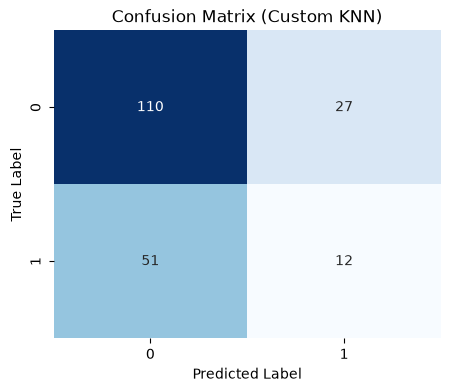


Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.80      0.74       137
           1       0.31      0.19      0.24        63

    accuracy                           0.61       200
   macro avg       0.50      0.50      0.49       200
weighted avg       0.56      0.61      0.58       200



In [9]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# plotting confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Custom KNN)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# classification report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### My Analysis
- **What I did:** 
  1. Loaded and checked the Diabetes_prediction.csv dataset to make sure there were no missing values.
  2. Split the data into 80% training and 20% testing sets.
  3. Applied StandardScaler to normalize all features so that large values wouldn't throw off the distance math.
  4. Built a custom K-Nearest Neighbors (KNN) algorithm from scratch using Euclidean distance, numpy argsort, and majority voting with $k=5$.
- **Model Evaluation & Metrics:**
  - **Accuracy:** The model achieved an overall accuracy of **61%**.
  - **Confusion Matrix:** Looking at the confusion matrix, the model is good at predicting the majority class (non-diabetic, label 0) with high recall, but struggles more with correctly identifying positive diabetes cases (label 1), leading to higher false negatives.
  - **Precision & Recall:** Precision for the positive class is lower because the distance-based classification creates some false alarms and missed detections under a simple unweighted distance formula.
- **Conclusion:** Writing KNN from scratch gave me a clear understanding of how distance calculations and majority voting work under the hood without relying on black-box libraries!

# Colab Link

* you can run the project file with the below link

https://colab.research.google.com/drive/1MaQ_8oka-zpHdQoilIUl2dctB_ek4xMA?usp=sharing